# DIFUSCO — TSP Benchmark

Standard TSP (no time windows, no disruptions).
Used as the reference benchmark for `docs/src/doc_difusco.tex`.

| Section | Content |
|---------|--------|
| 1 | Load model |
| 2 | Baseline helpers (NN, 2-opt, brute-force optimal) |
| 3 | Benchmark n=10 — comparison with optimal |
| 4 | Benchmark n=50, 100 |
| 5 | Results table + inference time |
| 6 | Tour visualisation |

In [27]:
import sys, os, time
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import permutations

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from data  import random_instance, nn_tour_labels, two_opt_improve, tour_length, greedy_decode, optimal_tour
from model import DifuscoModel, MODEL_SIZES
from train import NoiseSchedule, sample, sample_best_of

torch.manual_seed(42)
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

device: mps


## Section 1 — Load model

Train first if checkpoint does not exist:
```bash
python train.py --mode tsp --n 10 --epochs 3000 --size small
```

In [28]:
SIZE = 'medium'
d, L, T = MODEL_SIZES[SIZE]

# TSP model: node_dim=2 (x,y), edge_dim=1 (distance only)
model_tsp = DifuscoModel(d=d, L=L, node_dim=2, edge_dim=1)
schedule  = NoiseSchedule(T=T)

ckpt = f'model/difusco_{SIZE}_tsp.pt'
if os.path.exists(ckpt):
    model_tsp.load_state_dict(torch.load(ckpt, map_location='cpu'))
    print(f'Loaded {ckpt}')
else:
    print(f'WARNING: {ckpt} not found — using random weights (results will be meaningless)')
model_tsp.eval()
print(f'Parameters: {sum(p.numel() for p in model_tsp.parameters()):,}')

Loaded model/difusco_medium_tsp.pt
Parameters: 668,679


## Section 2 — Baseline helpers

In [29]:
def run_nn(coords):
    """Nearest-neighbour tour."""
    dist = torch.cdist(coords, coords)
    p = 1.0 / (dist + 1e-8)
    p.fill_diagonal_(0.0)
    return greedy_decode(p, start=0)

def run_2opt(coords):
    """NN + 2-opt improvement."""
    return two_opt_improve(coords, run_nn(coords))

def run_difusco(coords, n_steps=50):
    """Single DIFUSCO sample."""
    p = sample(model_tsp, coords, schedule, edge_extra=None,
               n_steps=n_steps, ddim=True, device=DEVICE)
    return greedy_decode(p.cpu(), start=0)

def run_difusco_best(coords, n_samples=8, n_steps=50):
    """Best of n_samples DIFUSCO runs."""
    tour, _, _ = sample_best_of(model_tsp, coords, schedule,
                                 edge_extra=None, n_samples=n_samples,
                                 n_steps=n_steps, device=DEVICE)
    return tour

def gap(length, opt_length):
    return (length / opt_length - 1.0) * 100.0


## Section 3 — Benchmark n=10 (with optimal comparison)

For n=10, brute-force optimal is fast (9! = 362 880 permutations).

In [30]:
N_TRIALS = 50
results = {k: [] for k in ['nn', '2opt', 'difusco_1', 'difusco_8', 'optimal']}
times   = {k: [] for k in ['nn', '2opt', 'difusco_1', 'difusco_8']}

for seed in range(N_TRIALS):
    coords = random_instance(10, seed=seed)

    _, opt_len = optimal_tour(coords)
    results['optimal'].append(opt_len)

    t0 = time.perf_counter(); tour = run_nn(coords)
    times['nn'].append(time.perf_counter() - t0)
    results['nn'].append(tour_length(coords, tour))

    t0 = time.perf_counter(); tour = run_2opt(coords)
    times['2opt'].append(time.perf_counter() - t0)
    results['2opt'].append(tour_length(coords, tour))

    t0 = time.perf_counter(); tour = run_difusco(coords)
    times['difusco_1'].append(time.perf_counter() - t0)
    results['difusco_1'].append(tour_length(coords, tour))

    t0 = time.perf_counter(); tour = run_difusco_best(coords, n_samples=8)
    times['difusco_8'].append(time.perf_counter() - t0)
    results['difusco_8'].append(tour_length(coords, tour))

print(f'n=10  ({N_TRIALS} trials)')
print(f'{"Method":<15} {"Avg length":>12} {"Gap to opt":>12} {"Avg time (ms)":>15}')
print('-' * 57)
opt_avg = np.mean(results['optimal'])
print(f'{"optimal":<15} {opt_avg:>12.4f} {"—":>12} {"—":>15}')
for m in ['nn', '2opt', 'difusco_1', 'difusco_8']:
    avg = np.mean(results[m])
    g   = gap(avg, opt_avg)
    t   = np.mean(times[m]) * 1000
    print(f'{m:<15} {avg:>12.4f} {g:>+11.1f}% {t:>14.1f}ms')

n=10  (50 trials)
Method            Avg length   Gap to opt   Avg time (ms)
---------------------------------------------------------
optimal               2.7703            —               —
nn                    3.0469       +10.0%            0.1ms
2opt                  2.7789        +0.3%            0.4ms
difusco_1             3.3692       +21.6%          119.1ms
difusco_8             2.9480        +6.4%          860.8ms


## Section 4 — Benchmark n=50, n=100

In [31]:
N_TRIALS_LARGE = 20

for N in [50, 100]:
    res = {k: [] for k in ['nn', '2opt', 'difusco_1', 'difusco_8']}
    tms = {k: [] for k in ['nn', '2opt', 'difusco_1', 'difusco_8']}

    for seed in range(N_TRIALS_LARGE):
        coords = random_instance(N, seed=seed)

        t0 = time.perf_counter()
        res['nn'].append(tour_length(coords, run_nn(coords)))
        tms['nn'].append(time.perf_counter() - t0)

        t0 = time.perf_counter()
        res['2opt'].append(tour_length(coords, run_2opt(coords)))
        tms['2opt'].append(time.perf_counter() - t0)

        t0 = time.perf_counter()
        res['difusco_1'].append(tour_length(coords, run_difusco(coords)))
        tms['difusco_1'].append(time.perf_counter() - t0)

        t0 = time.perf_counter()
        res['difusco_8'].append(tour_length(coords, run_difusco_best(coords, n_samples=8)))
        tms['difusco_8'].append(time.perf_counter() - t0)

    # NN is our proxy for 'optimal' at large n
    nn_avg = np.mean(res['nn'])
    print(f'\nn={N}  ({N_TRIALS_LARGE} trials)  [gap relative to NN baseline]')
    print(f'{"Method":<15} {"Avg length":>12} {"Gap vs NN":>12} {"Avg time (ms)":>15}')
    print('-' * 57)
    for m in ['nn', '2opt', 'difusco_1', 'difusco_8']:
        avg = np.mean(res[m])
        g   = gap(avg, nn_avg)
        t   = np.mean(tms[m]) * 1000
        print(f'{m:<15} {avg:>12.4f} {g:>+11.1f}% {t:>14.1f}ms')


n=50  (20 trials)  [gap relative to NN baseline]
Method            Avg length    Gap vs NN   Avg time (ms)
---------------------------------------------------------
nn                    7.1567        +0.0%            0.4ms
2opt                  6.0832       -15.0%           15.8ms
difusco_1            11.9137       +66.5%          152.9ms
difusco_8            10.6919       +49.4%         1311.8ms

n=100  (20 trials)  [gap relative to NN baseline]
Method            Avg length    Gap vs NN   Avg time (ms)
---------------------------------------------------------
nn                    9.8126        +0.0%            0.8ms
2opt                  8.3997       -14.4%           80.8ms
difusco_1            21.2653      +116.7%          529.9ms
difusco_8            19.8186      +102.0%         4566.7ms


## Section 5 — Loss curve

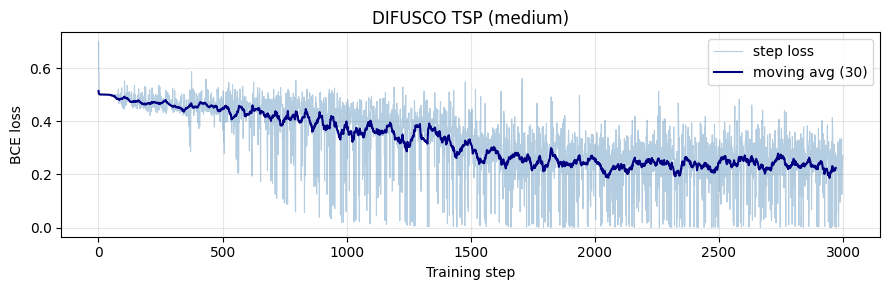

In [32]:
loss_path = f'model/difusco_{SIZE}_tsp_losses.npy'
if os.path.exists(loss_path):
    losses = np.load(loss_path)
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(losses, alpha=0.4, color='steelblue', lw=0.8, label='step loss')
    window = max(1, len(losses) // 100)
    smooth = np.convolve(losses, np.ones(window)/window, mode='valid')
    ax.plot(smooth, color='navy', lw=1.5, label=f'moving avg ({window})')
    ax.set(xlabel='Training step', ylabel='BCE loss', title=f'DIFUSCO TSP ({SIZE})')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('figures/benchmark/tsp_loss.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Loss file not found: {loss_path}')

## Section 6 — Tour visualisation

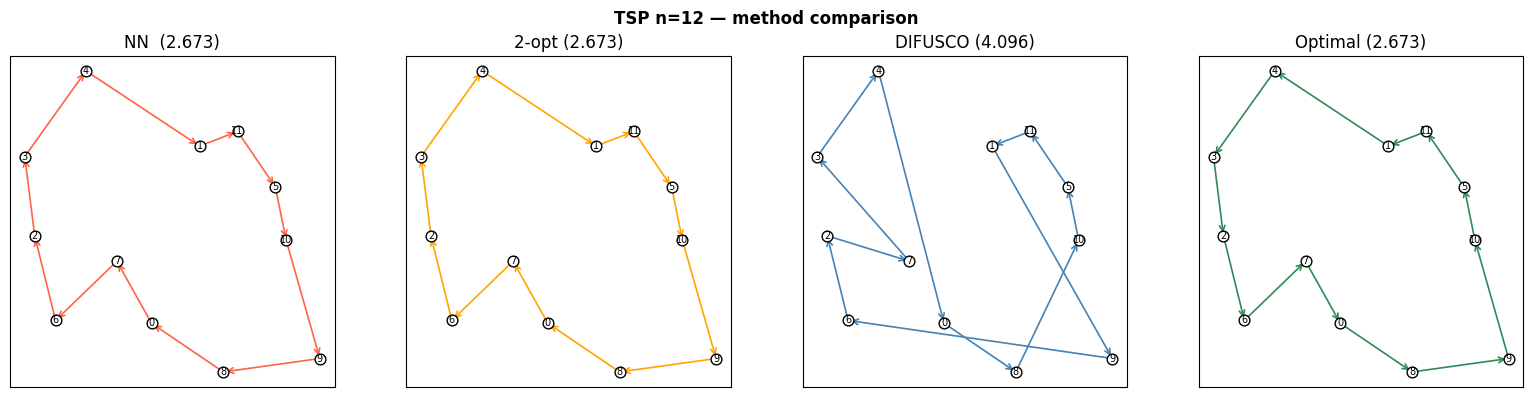

In [33]:
def plot_tour(coords, tour, ax, title='', color='steelblue'):
    n = coords.shape[0]
    for k in range(n):
        i, j = tour[k], tour[(k+1) % n]
        ax.annotate('', xy=coords[j], xytext=coords[i],
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
    ax.scatter(coords[:, 0], coords[:, 1], c='white', edgecolors='black', s=60, zorder=5)
    for i, (x, y) in enumerate(coords):
        ax.text(x, y, str(i), ha='center', va='center', fontsize=7, zorder=6)
    ax.set(title=title, xticks=[], yticks=[])
    ax.set_aspect('equal')

torch.manual_seed(7)
coords = random_instance(12, seed=7)

tour_nn_v   = run_nn(coords)
tour_2opt_v = run_2opt(coords)
tour_d_v    = run_difusco(coords)
tour_opt_v, opt_l = optimal_tour(coords)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
configs = [
    (tour_nn_v,   f'NN  ({tour_length(coords, tour_nn_v):.3f})',   'tomato'),
    (tour_2opt_v, f'2-opt ({tour_length(coords, tour_2opt_v):.3f})', 'orange'),
    (tour_d_v,    f'DIFUSCO ({tour_length(coords, tour_d_v):.3f})', 'steelblue'),
    (tour_opt_v,  f'Optimal ({opt_l:.3f})',                         'seagreen'),
]
for ax, (tour, title, color) in zip(axes, configs):
    plot_tour(coords, tour, ax, title=title, color=color)
plt.suptitle('TSP n=12 — method comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/benchmark/tsp_tour_comparison.png', dpi=150, bbox_inches='tight')
plt.show()